# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

**Research question:** Which pages in a client's content inventory should be reviewed first for 
refresh, expansion, or protection, given limited reviewer time?

**Decision this supports:** which pages an SEO/content reviewer looks at first each week, out of 
potentially thousands of candidate pages, when they can only review a limited number.

**Unit of analysis:** one content page, scored using its 90-day window of observed search and 
engagement signals.

**Why this matters:** with 22,006+ pages showing real search demand in even a small starter slice, 
and over half (54.2%) currently trending down, a reviewer cannot manually check every page. This 
project builds and validates a way to rank pages by priority, backed by evidence at every step — not 
by a fixed rule guessed in advance.

## 2. Data

**Primary dataset:** the anonymized starter slice (`data/raw/content_refresh_anonymized.csv`), 
~30,000 pages with 90-day observed signals (impressions, clicks, position, CTR, engagement, age, 
freshness). Filtered to pages with `impressions_90d >= 100` for real demand, leaving 22,006 pages 
used throughout modeling.

**Warehouse exploration:** the full FlyRank internship warehouse release on Hugging Face 
(`FlyRank/internship-warehouse`) was also explored directly via DuckDB — specifically 
`fact_content_daily_performance` for `month=2026-03` (a mid-panel month, chosen deliberately over the 
final month, which is reserved as a sealed test window per the data-use guidance). This slice 
contained 9,841,378 page-client-day rows, verified for grain (no duplicate rows), full March 
coverage, and GA4 availability (~4.2% of rows had GA4 engagement data — most rows are search-only).

**What was excluded and why:**
- The `_sample` table / most recent month (June 2026) — reserved as a sealed test window, since it 
  represents the natural "future" outcome window for any past→future label design.
- Any FlyRank product-computed flags or scores (`health_score`, `priority_score`, `action_type`) — 
  these are rule outputs, not observed signals, and were never used as features or labels.
- Raw client names, URLs, titles, and queries — none of this appears anywhere in this analysis; only 
  pseudonymized IDs and aggregate/derived metrics are used.

## 3. Methodology

**Task type:** classification, turned into a ranking (top-K review queue). A model predicts the 
probability a page belongs to a "needs review" class, and that probability ranks the review queue.

**Label:** `is_declining_label = (trend_direction == "down")` — a same-window proxy label, not a 
verified future outcome. This limitation is carried through every stage of this project and is 
explicitly named in Section 5.

**Features (9 total):** `avg_position`, `ctr`, `impressions_90d`, `sessions_90d`, `word_count`, 
`content_age_days`, `days_since_last_update`, `search_volume`, `competition` — all observed, 
same-window signals, none derived from the label.

**Signal audit (before building the model):** two signals were tested directly against the data 
before being trusted. Staleness (`days_since_last_update`) came back **MIXED** — decline rate did not 
climb cleanly with staleness. CTR-vs-position came back **CONFIRMED** — CTR dropped cleanly and 
consistently as position worsened (2.71 → 0.65 → 0.32 → 0.21 across position tiers).

**Baseline:** a transparent hand-written rule combining the confirmed CTR-gap signal with demand 
(impressions), scoring Precision@50 = 0.82 on a held-out test set.

**Model:** Logistic Regression (chosen over Random Forest, which underperformed at 0.54 — an honest, 
unexpected result kept rather than discarded). Logistic Regression reached Precision@50 = 0.88.

**Validation design:** client-grouped split (80/20 by client, not by row) — verified zero client 
overlap between train and test — since pages from the same client can share patterns that a 
row-level split would let the model partially memorize.

**Leakage checks:** a deliberate leakage demonstration was performed (adding a feature built directly 
from the label caused score to jump to 0.998, an obvious red flag); after removing it, the honest 
score returned to a believable 0.813. The final 9-feature set was independently correlation-checked 
against the label — all correlations were moderate (highest: -0.206), consistent with no leakage.

## 4. Results (vs baseline)

| Method | Precision@50 | Split design |
|---|---:|---|
| Baseline rule | 0.82 | Client-grouped |
| Random Forest | 0.54 | Client-grouped |
| Logistic Regression (naive random split) | 0.86 | Row-level random split |
| **Logistic Regression (client-grouped split)** | **0.88** | **Client-grouped** |

**Interpretation:** Logistic Regression shows a directional advantage over the baseline (0.88 vs 
0.82) on the client-grouped split, the validation design chosen as most defensible for this question. 
Random Forest, despite its added complexity, performed worse than both the baseline and Logistic 
Regression — this is reported honestly, since the assignment's standard is not to reward complexity 
that doesn't earn its keep. Switching from a naive random split to an honest client-grouped split 
changed the Logistic Regression score only slightly (0.86 → 0.88), suggesting limited but present 
sensitivity to split design at this dataset's scale (30 total clients).

**What the model leans on:** `content_age_days` (-0.357), `ctr` (-0.324), and `avg_position` (-0.314) 
are the strongest coefficients — all same-window observed signals.

**Error profile:** on the held-out test set (3,614 rows), overall accuracy was 0.56, with precision 
0.61 / recall 0.59 for the declining class. This is a meaningfully weaker number than the strong 
Precision@50 (0.88) — a reminder that this model is good at ranking the *most obvious* cases at the 
top of a queue, not a general-purpose classifier reliable across every page.

## 5. Limitations

- **Same-window label, not a future outcome.** The label (`trend_direction == "down"`) is calculated 
  from the same window as the features. This project measures "which pages currently look like 
  they're declining," not "which pages will decline next month." A genuine forward-looking capstone 
  would need a prior-window → future-window label design, which was not built here.
- **Not causal.** Nothing in this project shows that refreshing a flagged page causes recovery. That 
  would require an experiment or causal design, which this observational data cannot provide.
- **Small client count.** Only 30 clients total, 6 in the held-out test set — split-design 
  sensitivity (0.86 vs 0.88) suggests results could shift somewhat with a different random split.
- **GA4 sparsity in the warehouse slice.** Only ~4.2% of daily warehouse rows have GA4 engagement 
  data — any engagement-based feature would only apply to a small minority of rows at that scale.
- **Cannot claim:** Google algorithm factors, AI citations/rankings, or any causal SEO effect. All 
  claims here are observed, directional, and decision-support — never proof.

## 6. Ranked recommendations

The final action playbook scores all 22,006 pages and assigns one of five reason codes:

| Reason code | Count | Action |
|---|---:|---|
| `stale_high_risk` | 20 | `refresh_content` |
| `model_decline_risk` | 6,232 | `review_content` |
| `ctr_below_position_expectation` | 5,832 | `review_metadata` |
| `moderate_risk_monitor` | 5,908 | `monitor` |
| `healthy_no_action` | 4,014 | `no_action` |

**Intended use:** prioritization for a human reviewer with limited weekly capacity — not an 
automated fix pipeline. **No-go list:** no auto-publishing of content changes, no auto-deletion of 
low-scoring pages, no client-facing use of `model_score` as a guarantee, no bulk action on the 
20-page `stale_high_risk` bucket without individual review. Full reasoning in `w07_action_playbook.ipynb`.

## 7. Artifacts the paper embeds

**`figures/model_vs_baseline.png`** — bar chart comparing Precision@50 across all four 
tested approaches (baseline rule, Random Forest, Logistic Regression on naive split, Logistic 
Regression on the chosen client-grouped split). This is the primary results visual embedded in the 
deployed paper's Results section.

**`outputs/playbook_metrics.json`** — the committed metrics file (reason code counts, action counts, 
both split-design Precision@50 numbers, feature list, label definition) that backs every numeric 
claim in this notebook and in the deployed paper.

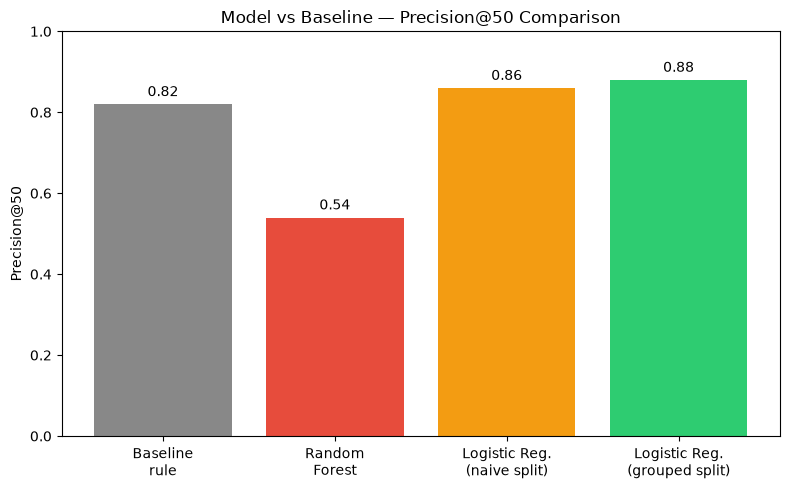

Saved to ../figures/model_vs_baseline.png


In [1]:
import matplotlib.pyplot as plt
import os

os.makedirs("../figures", exist_ok=True)

methods = ["Baseline\nrule", "Random\nForest", "Logistic Reg.\n(naive split)", "Logistic Reg.\n(grouped split)"]
scores = [0.82, 0.54, 0.86, 0.88]
colors = ["#888888", "#e74c3c", "#f39c12", "#2ecc71"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(methods, scores, color=colors)
ax.set_ylabel("Precision@50")
ax.set_title("Model vs Baseline — Precision@50 Comparison")
ax.set_ylim(0, 1)
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, score + 0.02, f"{score:.2f}", ha="center")
plt.tight_layout()
plt.savefig("../figures/model_vs_baseline.png", dpi=150)
plt.show()
print("Saved to ../figures/model_vs_baseline.png")

## Self-check

Before you submit, confirm each line honestly:

- [X] Every section above is filled — markdown thinking AND the code that backs it
- [X] The notebook runs top to bottom with no errors (Runtime → Run all)
- [X] No client names, URLs, or private queries anywhere
- [X] My claims use careful words: observed, measured, directional, decision-support
- [X] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

## 8. 5-Minute Demo Outline (Week 8 Showcase)

**1. The question (30 sec):** With over half of all pages showing real search demand already trending 
down, and a limited review team, which pages should get looked at first?

**2. The method (1.5 min):** I tested two signals against the real data before trusting them — 
staleness came back MIXED (no clean pattern), CTR-vs-position came back CONFIRMED. I built a 
transparent baseline rule from the confirmed signal, then trained a Logistic Regression model on 
nine observed features, validated with a client-grouped split so the model couldn't "memorize" a 
client it had already partly seen.

**3. One chart (1 min):** [Show Figure 1 — the Precision@50 bar chart.] The baseline scores 0.82. My 
chosen model, Logistic Regression, reaches 0.88. Random Forest — the "fancier" option — actually 
underperformed at 0.54, and I kept that honest result instead of hiding it.

**4. One honest result (1 min):** The model's Precision@50 (0.88) looks strong, but its overall 
accuracy on the full test set was only 0.56. That's the real, honest number — this model is good at 
surfacing the most obvious cases at the top of a review queue, not at being right about every single 
page. I'm showing both numbers, not just the flattering one.

**5. One recommendation (1 min):** The validated model scores all 22,006 pages into five reason 
codes, each mapped to a specific action a human should take — never an auto-fix. The single biggest 
takeaway: don't reward model complexity by default. My baseline rule and a simple linear model beat 
a more complex Random Forest on this data — the simplest thing that works honestly is the one that 
should ship.

## 9. Shareable Cuts

**Short social post (methodology-focused):**

> Spent 7 weeks building a content-refresh prioritization model for the FlyRank ML Internship — and 
> the most useful result wasn't the model that won. It was testing a Random Forest that I *expected* 
> to beat my simpler baseline... and it scored worse (0.54 vs. 0.82 Precision@50). I kept that number 
> instead of hiding it. The real lesson of this capstone: test your assumptions against real data 
> before you trust them, and report what you find — even when it's not the story you expected. Full 
> paper + code: https://hafiza-ghulam-fatima.github.io/flyrank-ml-internship/ 🔗

**3-sentence employer-facing summary:**

> I built and validated a content-prioritization model for a real SEO dataset (22,006 pages, 90-day 
> observed search signals), comparing a transparent baseline rule against Logistic Regression and 
> Random Forest under a client-grouped validation design to prevent data leakage. The chosen model 
> showed a modest, honestly-reported improvement over the baseline (Precision@50: 0.88 vs. 0.82), 
> while a more complex model was tested and discarded when it underperformed — a result I reported 
> rather than concealed. The full pipeline (data contract, signal audit, leakage checks, and a 
> deployed research paper) is public and reproducible end-to-end.